#Cell 1 — Project title and explanation

# AI-Powered E-commerce Order Exception Analyst

## Project Overview

This project simulates an e-commerce fulfilment operations workflow.

The aim is to analyse order data and automatically identify operational exceptions such as:

- Orders that are stuck or overdue
- Missing tracking information
- Quantity mismatches
- Late dispatches
- Missing invoices
- Other fulfilment inconsistencies

Python is used to clean and analyse the order data, detect exceptions and prioritise operational issues.

The final stage of the project will demonstrate how AI can be used to summarise exceptions and produce an actionable daily operations report.

### Tools
- Python
- Pandas
- NumPy
- Data analysis
- Rule-based exception detection
- AI-assisted operational reporting

In [2]:
#Cell 2 — Import Python libraries
import pandas as pd
import numpy as np

from datetime import datetime, timedelta

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
#Cell 3 — Create synthetic fulfilment data
# Set a random seed so the results are reproducible
np.random.seed(42)

# Number of synthetic orders
n_orders = 500

# Create order IDs
order_ids = [f"ORD{10001 + i}" for i in range(n_orders)]

# Possible sellers, warehouses and carriers
sellers = ["Seller_A", "Seller_B", "Seller_C", "Seller_D"]
warehouses = ["Nottingham", "Birmingham", "Manchester"]
carriers = ["DPD", "Royal Mail", "Evri", "DHL"]

# Generate order dates
start_date = datetime(2026, 7, 1)

order_dates = [
    start_date + timedelta(days=int(x))
    for x in np.random.randint(0, 40, n_orders)
]

# Expected dispatch is normally 1–3 days after order
expected_dispatch_dates = [
    d + timedelta(days=int(x))
    for d, x in zip(order_dates, np.random.randint(1, 4, n_orders))
]

# Create basic dataset
orders = pd.DataFrame({
    "Order_ID": order_ids,
    "Seller": np.random.choice(sellers, n_orders),
    "Warehouse": np.random.choice(warehouses, n_orders),
    "Carrier": np.random.choice(carriers, n_orders),
    "Order_Date": order_dates,
    "Expected_Dispatch_Date": expected_dispatch_dates,
    "Expected_Quantity": np.random.randint(1, 6, n_orders)
})

orders.head()

,Order_ID,Seller,Warehouse,Carrier,Order_Date,Expected_Dispatch_Date,Expected_Quantity
0,ORD10001,Seller_C,Nottingham,DHL,2026-08-08,2026-08-11,2
1,ORD10002,Seller_B,Nottingham,DHL,2026-07-29,2026-08-01,3
2,ORD10003,Seller_B,Nottingham,DHL,2026-07-15,2026-07-17,5
3,ORD10004,Seller_B,Nottingham,Royal Mail,2026-07-08,2026-07-11,4
4,ORD10005,Seller_D,Nottingham,Royal Mail,2026-07-21,2026-07-22,2


In [4]:
#Cell 4 — Add fulfilment status fields
# Create an initial order status
orders["Order_Status"] = np.random.choice(
    ["Processing", "Shipped", "Delivered"],
    size=n_orders,
    p=[0.25, 0.45, 0.30]
)

# Create actual dispatch dates
orders["Actual_Dispatch_Date"] = orders["Expected_Dispatch_Date"].copy()

# Add some random dispatch delays of 0–3 days
dispatch_delay = np.random.randint(0, 4, n_orders)

orders["Actual_Dispatch_Date"] = (
    orders["Actual_Dispatch_Date"]
    + pd.to_timedelta(dispatch_delay, unit="D")
)

# Processing orders have not yet dispatched
orders.loc[
    orders["Order_Status"] == "Processing",
    "Actual_Dispatch_Date"
] = pd.NaT

# Create shipped quantity
orders["Shipped_Quantity"] = orders["Expected_Quantity"]

# Create tracking numbers
orders["Tracking_Number"] = [
    f"TRK{200000 + i}" if status in ["Shipped", "Delivered"] else np.nan
    for i, status in enumerate(orders["Order_Status"])
]

# Create invoice status
orders["Invoice_Status"] = np.where(
    orders["Order_Status"] == "Delivered",
    "Generated",
    "Pending"
)

orders.head(10)

,Order_ID,Seller,Warehouse,Carrier,Order_Date,Expected_Dispatch_Date,Expected_Quantity,Order_Status,Actual_Dispatch_Date,Shipped_Quantity,Tracking_Number,Invoice_Status
0,ORD10001,Seller_C,Nottingham,DHL,2026-08-08,2026-08-11,2,Shipped,2026-08-13,2,TRK200000,Pending
1,ORD10002,Seller_B,Nottingham,DHL,2026-07-29,2026-08-01,3,Delivered,2026-08-04,3,TRK200001,Generated
2,ORD10003,Seller_B,Nottingham,DHL,2026-07-15,2026-07-17,5,Delivered,2026-07-18,5,TRK200002,Generated
3,ORD10004,Seller_B,Nottingham,Royal Mail,2026-07-08,2026-07-11,4,Delivered,2026-07-14,4,TRK200003,Generated
4,ORD10005,Seller_D,Nottingham,Royal Mail,2026-07-21,2026-07-22,2,Delivered,2026-07-23,2,TRK200004,Generated
5,ORD10006,Seller_A,Nottingham,Royal Mail,2026-08-08,2026-08-09,3,Processing,NaT,3,NaN,Pending
6,ORD10007,Seller_A,Nottingham,Royal Mail,2026-07-19,2026-07-22,4,Shipped,2026-07-25,4,TRK200006,Pending
7,ORD10008,Seller_B,Manchester,Evri,2026-07-23,2026-07-24,4,Delivered,2026-07-25,4,TRK200007,Generated
8,ORD10009,Seller_A,Birmingham,Evri,2026-07-11,2026-07-14,2,Processing,NaT,2,NaN,Pending
9,ORD10010,Seller_B,Nottingham,Evri,2026-07-11,2026-07-12,1,Delivered,2026-07-12,1,TRK200009,Generated


In [5]:
#Cell 5 — Deliberately create operational problems
# Create copies of random order indices for each exception type

missing_tracking_idx = orders[
    orders["Order_Status"].isin(["Shipped", "Delivered"])
].sample(20, random_state=1).index

quantity_mismatch_idx = orders.sample(15, random_state=2).index

missing_invoice_idx = orders[
    orders["Order_Status"] == "Delivered"
].sample(15, random_state=3).index

stuck_order_idx = orders[
    orders["Order_Status"] == "Processing"
].sample(20, random_state=4).index


# 1. Missing tracking numbers
orders.loc[missing_tracking_idx, "Tracking_Number"] = np.nan


# 2. Quantity mismatches
orders.loc[
    quantity_mismatch_idx,
    "Shipped_Quantity"
] = np.maximum(
    0,
    orders.loc[quantity_mismatch_idx, "Expected_Quantity"] - 1
)


# 3. Delivered orders with missing invoices
orders.loc[
    missing_invoice_idx,
    "Invoice_Status"
] = "Missing"


# 4. Create stuck orders by moving expected dispatch date into the past
orders.loc[
    stuck_order_idx,
    "Expected_Dispatch_Date"
] = pd.Timestamp("2026-08-10")


print("Operational exceptions introduced successfully.")

Operational exceptions introduced successfully.


In [6]:
#Cell 6 — Quick quality check
print("Dataset size:", orders.shape)

print("\nOrder status counts:")
print(orders["Order_Status"].value_counts())

print("\nMissing tracking numbers:")
print(orders["Tracking_Number"].isna().sum())

print("\nMissing invoices:")
print((orders["Invoice_Status"] == "Missing").sum())

print("\nQuantity mismatches:")
print(
    (orders["Expected_Quantity"] != orders["Shipped_Quantity"]).sum()
)

Dataset size: (500, 12)

Order status counts:
Order_Status
Shipped       214
Delivered     155
Processing    131
Name: count, dtype: int64

Missing tracking numbers:
151

Missing invoices:
15

Quantity mismatches:
15


In [7]:
#cell7
# Count only genuine tracking exceptions:
# shipped or delivered orders with no tracking number

genuine_missing_tracking = orders[
    orders["Order_Status"].isin(["Shipped", "Delivered"])
    & orders["Tracking_Number"].isna()
]

print("Genuine missing tracking exceptions:", len(genuine_missing_tracking))

print("\nMissing invoices:")
print((orders["Invoice_Status"] == "Missing").sum())

print("\nQuantity mismatches:")
print(
    (orders["Expected_Quantity"] != orders["Shipped_Quantity"]).sum()
)

Genuine missing tracking exceptions: 20

Missing invoices:
15

Quantity mismatches:
15


In [8]:
#cell8
# Set a simulated current date for the analysis
analysis_date = pd.Timestamp("2026-08-17")

# Create exception flags

orders["Missing_Tracking"] = (
    orders["Order_Status"].isin(["Shipped", "Delivered"])
    & orders["Tracking_Number"].isna()
)

orders["Quantity_Mismatch"] = (
    orders["Expected_Quantity"] != orders["Shipped_Quantity"]
)

orders["Missing_Invoice"] = (
    (orders["Order_Status"] == "Delivered")
    & (orders["Invoice_Status"] == "Missing")
)

orders["Stuck_Order"] = (
    (orders["Order_Status"] == "Processing")
    & (orders["Expected_Dispatch_Date"] < analysis_date)
)

orders["Late_Dispatch"] = (
    orders["Actual_Dispatch_Date"].notna()
    & (
        orders["Actual_Dispatch_Date"]
        > orders["Expected_Dispatch_Date"]
    )
)

print("Exception detection complete.")

Exception detection complete.


In [9]:
#cell9
exception_counts = pd.Series({
    "Missing Tracking": orders["Missing_Tracking"].sum(),
    "Quantity Mismatch": orders["Quantity_Mismatch"].sum(),
    "Missing Invoice": orders["Missing_Invoice"].sum(),
    "Stuck Order": orders["Stuck_Order"].sum(),
    "Late Dispatch": orders["Late_Dispatch"].sum()
})

print("Operational Exception Summary")
print("-----------------------------")
print(exception_counts)

Operational Exception Summary
-----------------------------
Missing Tracking      20
Quantity Mismatch     15
Missing Invoice       15
Stuck Order          131
Late Dispatch        271
dtype: int64


In [10]:
#Cell 10 — Make the simulated data more realistic
# ---------------------------------------------------------
# Improve the realism of the synthetic operational data
# ---------------------------------------------------------

analysis_date = pd.Timestamp("2026-08-17")

# Identify processing orders that were NOT deliberately selected
# to become stuck orders
processing_indices = orders[
    orders["Order_Status"] == "Processing"
].index

normal_processing_indices = processing_indices.difference(stuck_order_idx)

# Give normal processing orders future expected dispatch dates
future_days = np.random.randint(
    1,
    4,
    size=len(normal_processing_indices)
)

orders.loc[
    normal_processing_indices,
    "Expected_Dispatch_Date"
] = analysis_date + pd.to_timedelta(future_days, unit="D")


# ---------------------------------------------------------
# Rebuild realistic dispatch dates
# ---------------------------------------------------------

dispatched_mask = orders[
    "Order_Status"
].isin(["Shipped", "Delivered"])

# Most dispatched orders will be on time
orders.loc[
    dispatched_mask,
    "Actual_Dispatch_Date"
] = orders.loc[
    dispatched_mask,
    "Expected_Dispatch_Date"
]

# Select around 15% of dispatched orders to be late
late_indices = orders[
    dispatched_mask
].sample(
    frac=0.15,
    random_state=10
).index

# Give late orders a delay of 1–3 days
late_days = np.random.randint(
    1,
    4,
    size=len(late_indices)
)

orders.loc[
    late_indices,
    "Actual_Dispatch_Date"
] = (
    orders.loc[
        late_indices,
        "Expected_Dispatch_Date"
    ]
    + pd.to_timedelta(late_days, unit="D")
)

print("Synthetic operational data updated.")

Synthetic operational data updated.


In [11]:
#Cell 11 — Recalculate the exception flags
orders["Missing_Tracking"] = (
    orders["Order_Status"].isin(["Shipped", "Delivered"])
    & orders["Tracking_Number"].isna()
)

orders["Quantity_Mismatch"] = (
    orders["Expected_Quantity"]
    != orders["Shipped_Quantity"]
)

orders["Missing_Invoice"] = (
    (orders["Order_Status"] == "Delivered")
    & (orders["Invoice_Status"] == "Missing")
)

orders["Stuck_Order"] = (
    (orders["Order_Status"] == "Processing")
    & (
        orders["Expected_Dispatch_Date"]
        < analysis_date
    )
)

orders["Late_Dispatch"] = (
    orders["Actual_Dispatch_Date"].notna()
    & (
        orders["Actual_Dispatch_Date"]
        > orders["Expected_Dispatch_Date"]
    )
)

print("Exception flags recalculated.")

Exception flags recalculated.


In [12]:
#Cell 12 — Check our improved exception profile
exception_counts = pd.Series({
    "Missing Tracking": orders["Missing_Tracking"].sum(),
    "Quantity Mismatch": orders["Quantity_Mismatch"].sum(),
    "Missing Invoice": orders["Missing_Invoice"].sum(),
    "Stuck Order": orders["Stuck_Order"].sum(),
    "Late Dispatch": orders["Late_Dispatch"].sum()
})

print("Operational Exception Summary")
print("-----------------------------")
print(exception_counts)

Operational Exception Summary
-----------------------------
Missing Tracking     20
Quantity Mismatch    15
Missing Invoice      15
Stuck Order          20
Late Dispatch        55
dtype: int64


In [13]:
#Cell 13 — Build an exception description
def build_exception_reason(row):
    reasons = []

    if row["Missing_Tracking"]:
        reasons.append("Missing Tracking")

    if row["Quantity_Mismatch"]:
        reasons.append("Quantity Mismatch")

    if row["Missing_Invoice"]:
        reasons.append("Missing Invoice")

    if row["Stuck_Order"]:
        reasons.append("Stuck Order")

    if row["Late_Dispatch"]:
        reasons.append("Late Dispatch")

    if reasons:
        return " + ".join(reasons)

    return "No Exception"


orders["Exception_Reason"] = orders.apply(
    build_exception_reason,
    axis=1
)

orders[[
    "Order_ID",
    "Exception_Reason"
]].head(10)

,Order_ID,Exception_Reason
0,ORD10001,No Exception
1,ORD10002,Quantity Mismatch + Late Dispatch
2,ORD10003,No Exception
3,ORD10004,No Exception
4,ORD10005,Missing Invoice
5,ORD10006,No Exception
6,ORD10007,Missing Tracking
7,ORD10008,Late Dispatch
8,ORD10009,Stuck Order
9,ORD10010,No Exception


In [14]:
#Cell 14 — Create priority scoring
def assign_priority(row):

    score = 0

    # Higher-risk operational issues
    if row["Stuck_Order"]:
        score += 3

    if row["Quantity_Mismatch"]:
        score += 3

    if row["Missing_Tracking"]:
        score += 2

    if row["Missing_Invoice"]:
        score += 2

    if row["Late_Dispatch"]:
        score += 1

    # Convert score into operational priority
    if score >= 5:
        return "CRITICAL"

    elif score >= 3:
        return "HIGH"

    elif score >= 1:
        return "MEDIUM"

    else:
        return "NONE"


orders["Priority"] = orders.apply(
    assign_priority,
    axis=1
)

print(orders["Priority"].value_counts())

Priority
NONE      389
MEDIUM     67
HIGH       44
Name: count, dtype: int64


In [15]:
#Cell 15 — Recommended operational action
def recommend_action(row):

    actions = []

    if row["Stuck_Order"]:
        actions.append(
            "Investigate fulfilment status and contact warehouse"
        )

    if row["Quantity_Mismatch"]:
        actions.append(
            "Verify picked and shipped quantities with warehouse"
        )

    if row["Missing_Tracking"]:
        actions.append(
            "Check carrier integration and obtain tracking number"
        )

    if row["Missing_Invoice"]:
        actions.append(
            "Check billing workflow and generate invoice"
        )

    if row["Late_Dispatch"]:
        actions.append(
            "Review cause of dispatch delay"
        )

    if actions:
        return " | ".join(actions)

    return "No action required"


orders["Recommended_Action"] = orders.apply(
    recommend_action,
    axis=1
)

In [16]:
#Cell 16 — Create the operational exception queue
exception_queue = orders[
    orders["Exception_Reason"] != "No Exception"
].copy()

priority_order = {
    "CRITICAL": 1,
    "HIGH": 2,
    "MEDIUM": 3
}

exception_queue["Priority_Rank"] = (
    exception_queue["Priority"]
    .map(priority_order)
)

exception_queue = exception_queue.sort_values(
    by=["Priority_Rank", "Expected_Dispatch_Date"]
)

exception_queue = exception_queue[[
    "Order_ID",
    "Seller",
    "Warehouse",
    "Carrier",
    "Order_Status",
    "Expected_Dispatch_Date",
    "Exception_Reason",
    "Priority",
    "Recommended_Action"
]]

exception_queue.head(20)

,Order_ID,Seller,Warehouse,Carrier,Order_Status,Expected_Dispatch_Date,Exception_Reason,Priority,Recommended_Action
317,ORD10318,Seller_D,Birmingham,DPD,Shipped,2026-07-05,Quantity Mismatch,HIGH,Verify picked and shipped quantities with ware...
375,ORD10376,Seller_A,Manchester,DPD,Delivered,2026-07-11,Quantity Mismatch,HIGH,Verify picked and shipped quantities with ware...
384,ORD10385,Seller_A,Birmingham,Royal Mail,Shipped,2026-07-17,Quantity Mismatch,HIGH,Verify picked and shipped quantities with ware...
197,ORD10198,Seller_C,Manchester,Royal Mail,Delivered,2026-07-18,Missing Tracking + Late Dispatch,HIGH,Check carrier integration and obtain tracking ...
227,ORD10228,Seller_B,Nottingham,Royal Mail,Delivered,2026-07-19,Missing Invoice + Late Dispatch,HIGH,Check billing workflow and generate invoice | ...
273,ORD10274,Seller_C,Manchester,Evri,Delivered,2026-07-25,Missing Invoice + Late Dispatch,HIGH,Check billing workflow and generate invoice | ...
313,ORD10314,Seller_C,Birmingham,DPD,Shipped,2026-07-25,Missing Tracking + Late Dispatch,HIGH,Check carrier integration and obtain tracking ...
346,ORD10347,Seller_B,Manchester,Evri,Shipped,2026-07-25,Quantity Mismatch + Late Dispatch,HIGH,Verify picked and shipped quantities with ware...
118,ORD10119,Seller_A,Birmingham,Royal Mail,Delivered,2026-07-28,Missing Invoice + Late Dispatch,HIGH,Check billing workflow and generate invoice | ...
280,ORD10281,Seller_B,Birmingham,DPD,Shipped,2026-07-30,Quantity Mismatch,HIGH,Verify picked and shipped quantities with ware...


In [17]:
#Cell 17 — Show priority distribution
print("Priority Summary")
print("----------------")
print(exception_queue["Priority"].value_counts())

print("\nTotal orders analysed:", len(orders))
print("Orders requiring action:", len(exception_queue))
print(
    "Exception rate:",
    round(len(exception_queue) / len(orders) * 100, 1),
    "%"
)

Priority Summary
----------------
Priority
MEDIUM    67
HIGH      44
Name: count, dtype: int64

Total orders analysed: 500
Orders requiring action: 111
Exception rate: 22.2 %


In [18]:
#Cell 18 — Which warehouse has the most exceptions?
warehouse_analysis = (
    exception_queue
    .groupby("Warehouse")
    .agg(
        Exception_Orders=("Order_ID", "count"),
        High_Priority=("Priority", lambda x: (x == "HIGH").sum()),
        Medium_Priority=("Priority", lambda x: (x == "MEDIUM").sum())
    )
    .sort_values("Exception_Orders", ascending=False)
)

print("Warehouse Exception Analysis")
print("----------------------------")
print(warehouse_analysis)

Warehouse Exception Analysis
----------------------------
            Exception_Orders  High_Priority  Medium_Priority
Warehouse                                                   
Birmingham                43             14               29
Manchester                35             16               19
Nottingham                33             14               19


In [19]:
#Cell 19 — Which seller has the most exceptions?
seller_analysis = (
    exception_queue
    .groupby("Seller")
    .agg(
        Exception_Orders=("Order_ID", "count"),
        High_Priority=("Priority", lambda x: (x == "HIGH").sum()),
        Medium_Priority=("Priority", lambda x: (x == "MEDIUM").sum())
    )
    .sort_values("Exception_Orders", ascending=False)
)

print("Seller Exception Analysis")
print("-------------------------")
print(seller_analysis)

Seller Exception Analysis
-------------------------
          Exception_Orders  High_Priority  Medium_Priority
Seller                                                    
Seller_A                30             11               19
Seller_B                29             15               14
Seller_D                29              8               21
Seller_C                23             10               13


In [20]:
#Cell 20 — Which carrier has the most exceptions?
carrier_analysis = (
    exception_queue
    .groupby("Carrier")
    .agg(
        Exception_Orders=("Order_ID", "count"),
        High_Priority=("Priority", lambda x: (x == "HIGH").sum()),
        Medium_Priority=("Priority", lambda x: (x == "MEDIUM").sum())
    )
    .sort_values("Exception_Orders", ascending=False)
)

print("Carrier Exception Analysis")
print("--------------------------")
print(carrier_analysis)

Carrier Exception Analysis
--------------------------
            Exception_Orders  High_Priority  Medium_Priority
Carrier                                                     
DHL                       35             16               19
Royal Mail                33             12               21
DPD                       23              9               14
Evri                      20              7               13


In [21]:
#Cell 21 — Exception type breakdown
exception_type_summary = pd.Series({
    "Missing Tracking": orders["Missing_Tracking"].sum(),
    "Quantity Mismatch": orders["Quantity_Mismatch"].sum(),
    "Missing Invoice": orders["Missing_Invoice"].sum(),
    "Stuck Order": orders["Stuck_Order"].sum(),
    "Late Dispatch": orders["Late_Dispatch"].sum()
}).sort_values(ascending=False)

print("Exception Type Breakdown")
print("------------------------")
print(exception_type_summary)

Exception Type Breakdown
------------------------
Late Dispatch        55
Missing Tracking     20
Stuck Order          20
Missing Invoice      15
Quantity Mismatch    15
dtype: int64


In [22]:
#Cell 22 — Management dashboard summary
top_warehouse = warehouse_analysis.index[0]
top_seller = seller_analysis.index[0]
top_carrier = carrier_analysis.index[0]
most_common_exception = exception_type_summary.index[0]

print("=" * 55)
print("DAILY E-COMMERCE OPERATIONS SUMMARY")
print("=" * 55)

print(f"Total orders analysed: {len(orders)}")
print(f"Orders requiring action: {len(exception_queue)}")
print(
    f"Exception rate: "
    f"{len(exception_queue) / len(orders) * 100:.1f}%"
)

print()
print("Priority breakdown:")
print(
    f"High priority: "
    f"{(exception_queue['Priority'] == 'HIGH').sum()}"
)
print(
    f"Medium priority: "
    f"{(exception_queue['Priority'] == 'MEDIUM').sum()}"
)

print()
print(f"Most common exception: {most_common_exception}")
print(f"Warehouse with most exception orders: {top_warehouse}")
print(f"Seller with most exception orders: {top_seller}")
print(f"Carrier with most exception orders: {top_carrier}")

print("=" * 55)

DAILY E-COMMERCE OPERATIONS SUMMARY
Total orders analysed: 500
Orders requiring action: 111
Exception rate: 22.2%

Priority breakdown:
High priority: 44
Medium priority: 67

Most common exception: Late Dispatch
Warehouse with most exception orders: Birmingham
Seller with most exception orders: Seller_A
Carrier with most exception orders: DHL


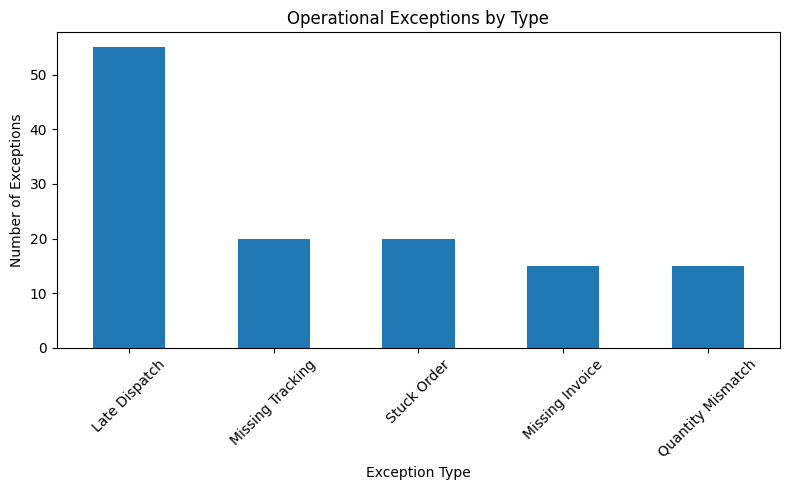

In [23]:
#Cell 23 — Visualise exception types
import matplotlib.pyplot as plt

exception_type_summary.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Operational Exceptions by Type")
plt.xlabel("Exception Type")
plt.ylabel("Number of Exceptions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

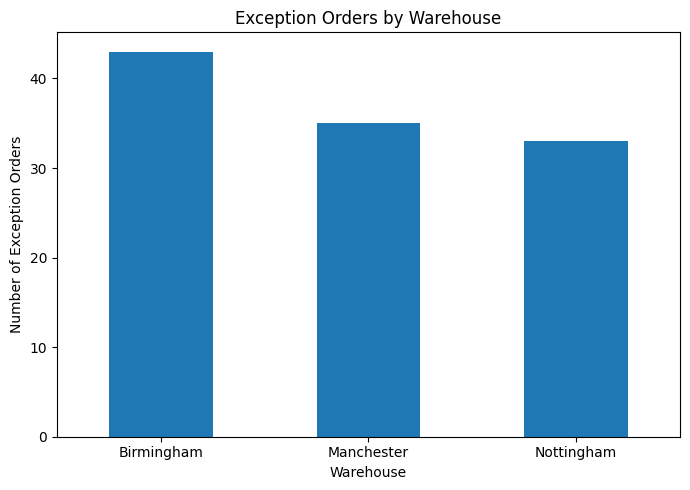

In [24]:
#Cell 24 — Visualise warehouse performance
warehouse_analysis["Exception_Orders"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Exception Orders by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Number of Exception Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
#Cell 25 — Export the exception queue
exception_queue.to_csv(
    "daily_order_exception_queue.csv",
    index=False
)

print("Exception queue exported successfully.")
print("File: daily_order_exception_queue.csv")

Exception queue exported successfully.
File: daily_order_exception_queue.csv


In [26]:
#Cell 26 — Create an AI-ready operational summary
ai_summary = f"""
DAILY E-COMMERCE OPERATIONS DATA

Total orders analysed: {len(orders)}

Orders requiring action: {len(exception_queue)}

Exception rate:
{len(exception_queue) / len(orders) * 100:.1f}%

PRIORITY BREAKDOWN
High priority orders:
{(exception_queue['Priority'] == 'HIGH').sum()}

Medium priority orders:
{(exception_queue['Priority'] == 'MEDIUM').sum()}

EXCEPTION TYPES
{exception_type_summary.to_string()}

WAREHOUSE ANALYSIS
{warehouse_analysis.to_string()}

SELLER ANALYSIS
{seller_analysis.to_string()}

CARRIER ANALYSIS
{carrier_analysis.to_string()}
"""

print(ai_summary)


DAILY E-COMMERCE OPERATIONS DATA

Total orders analysed: 500

Orders requiring action: 111

Exception rate:
22.2%

PRIORITY BREAKDOWN
High priority orders:
44

Medium priority orders:
67

EXCEPTION TYPES
Late Dispatch        55
Missing Tracking     20
Stuck Order          20
Missing Invoice      15
Quantity Mismatch    15

WAREHOUSE ANALYSIS
            Exception_Orders  High_Priority  Medium_Priority
Warehouse                                                   
Birmingham                43             14               29
Manchester                35             16               19
Nottingham                33             14               19

SELLER ANALYSIS
          Exception_Orders  High_Priority  Medium_Priority
Seller                                                    
Seller_A                30             11               19
Seller_B                29             15               14
Seller_D                29              8               21
Seller_C                23            

In [27]:
#Cell 27 — Count how many exception types each order has
exception_flag_columns = [
    "Missing_Tracking",
    "Quantity_Mismatch",
    "Missing_Invoice",
    "Stuck_Order",
    "Late_Dispatch"
]

orders["Exception_Count"] = orders[
    exception_flag_columns
].sum(axis=1)

print("Exception count distribution")
print("----------------------------")
print(
    orders["Exception_Count"]
    .value_counts()
    .sort_index()
)

Exception count distribution
----------------------------
Exception_Count
0    389
1     97
2     14
Name: count, dtype: int64


In [28]:
#Cell 28 — Identify multi-exception orders
multi_exception_orders = orders[
    orders["Exception_Count"] >= 2
].copy()

print(
    "Orders with multiple exception types:",
    len(multi_exception_orders)
)

print("\nMaximum exceptions on a single order:")
print(
    orders["Exception_Count"].max()
)

multi_exception_orders[[
    "Order_ID",
    "Seller",
    "Warehouse",
    "Carrier",
    "Order_Status",
    "Exception_Reason",
    "Exception_Count",
    "Priority"
]].sort_values(
    "Exception_Count",
    ascending=False
).head(20)

Orders with multiple exception types: 14

Maximum exceptions on a single order:
2


,Order_ID,Seller,Warehouse,Carrier,Order_Status,Exception_Reason,Exception_Count,Priority
1,ORD10002,Seller_B,Nottingham,DHL,Delivered,Quantity Mismatch + Late Dispatch,2,HIGH
118,ORD10119,Seller_A,Birmingham,Royal Mail,Delivered,Missing Invoice + Late Dispatch,2,HIGH
134,ORD10135,Seller_D,Nottingham,DPD,Shipped,Missing Tracking + Late Dispatch,2,HIGH
160,ORD10161,Seller_B,Manchester,Evri,Delivered,Missing Invoice + Late Dispatch,2,HIGH
197,ORD10198,Seller_C,Manchester,Royal Mail,Delivered,Missing Tracking + Late Dispatch,2,HIGH
225,ORD10226,Seller_D,Nottingham,DHL,Delivered,Quantity Mismatch + Late Dispatch,2,HIGH
227,ORD10228,Seller_B,Nottingham,Royal Mail,Delivered,Missing Invoice + Late Dispatch,2,HIGH
273,ORD10274,Seller_C,Manchester,Evri,Delivered,Missing Invoice + Late Dispatch,2,HIGH
313,ORD10314,Seller_C,Birmingham,DPD,Shipped,Missing Tracking + Late Dispatch,2,HIGH
346,ORD10347,Seller_B,Manchester,Evri,Shipped,Quantity Mismatch + Late Dispatch,2,HIGH


In [29]:
#Cell 29 — Check Late Dispatch + Missing Tracking overlap
late_and_missing_tracking = orders[
    orders["Late_Dispatch"]
    & orders["Missing_Tracking"]
]

print(
    "Orders with BOTH Late Dispatch and Missing Tracking:",
    len(late_and_missing_tracking)
)

late_and_missing_tracking[[
    "Order_ID",
    "Seller",
    "Warehouse",
    "Carrier",
    "Expected_Dispatch_Date",
    "Actual_Dispatch_Date",
    "Tracking_Number",
    "Priority"
]].head(20)

Orders with BOTH Late Dispatch and Missing Tracking: 4


,Order_ID,Seller,Warehouse,Carrier,Expected_Dispatch_Date,Actual_Dispatch_Date,Tracking_Number,Priority
134,ORD10135,Seller_D,Nottingham,DPD,2026-08-06,2026-08-09,NaN,HIGH
197,ORD10198,Seller_C,Manchester,Royal Mail,2026-07-18,2026-07-19,NaN,HIGH
313,ORD10314,Seller_C,Birmingham,DPD,2026-07-25,2026-07-28,NaN,HIGH
354,ORD10355,Seller_B,Nottingham,DHL,2026-08-05,2026-08-08,NaN,HIGH


In [30]:
#Cell 30 — High-priority rate by warehouse
warehouse_priority_rate = (
    exception_queue
    .groupby("Warehouse")
    .agg(
        Exception_Orders=("Order_ID", "count"),
        High_Priority_Orders=(
            "Priority",
            lambda x: (x == "HIGH").sum()
        )
    )
)

warehouse_priority_rate[
    "High_Priority_Rate"
] = (
    warehouse_priority_rate[
        "High_Priority_Orders"
    ]
    / warehouse_priority_rate[
        "Exception_Orders"
    ]
    * 100
).round(1)

warehouse_priority_rate = (
    warehouse_priority_rate
    .sort_values(
        "High_Priority_Rate",
        ascending=False
    )
)

print("Warehouse High-Priority Analysis")
print("--------------------------------")
print(warehouse_priority_rate)

Warehouse High-Priority Analysis
--------------------------------
            Exception_Orders  High_Priority_Orders  High_Priority_Rate
Warehouse                                                             
Manchester                35                    16                45.7
Nottingham                33                    14                42.4
Birmingham                43                    14                32.6


In [31]:
#Cell 31 — High-priority rate by seller
seller_priority_rate = (
    exception_queue
    .groupby("Seller")
    .agg(
        Exception_Orders=("Order_ID", "count"),
        High_Priority_Orders=(
            "Priority",
            lambda x: (x == "HIGH").sum()
        )
    )
)

seller_priority_rate[
    "High_Priority_Rate"
] = (
    seller_priority_rate[
        "High_Priority_Orders"
    ]
    / seller_priority_rate[
        "Exception_Orders"
    ]
    * 100
).round(1)

seller_priority_rate = (
    seller_priority_rate
    .sort_values(
        "High_Priority_Rate",
        ascending=False
    )
)

print("Seller High-Priority Analysis")
print("-----------------------------")
print(seller_priority_rate)

Seller High-Priority Analysis
-----------------------------
          Exception_Orders  High_Priority_Orders  High_Priority_Rate
Seller                                                              
Seller_B                29                    15                51.7
Seller_C                23                    10                43.5
Seller_A                30                    11                36.7
Seller_D                29                     8                27.6


In [32]:
#Cell 32 — High-priority rate by carrier
carrier_priority_rate = (
    exception_queue
    .groupby("Carrier")
    .agg(
        Exception_Orders=("Order_ID", "count"),
        High_Priority_Orders=(
            "Priority",
            lambda x: (x == "HIGH").sum()
        )
    )
)

carrier_priority_rate[
    "High_Priority_Rate"
] = (
    carrier_priority_rate[
        "High_Priority_Orders"
    ]
    / carrier_priority_rate[
        "Exception_Orders"
    ]
    * 100
).round(1)

carrier_priority_rate = (
    carrier_priority_rate
    .sort_values(
        "High_Priority_Rate",
        ascending=False
    )
)

print("Carrier High-Priority Analysis")
print("------------------------------")
print(carrier_priority_rate)

Carrier High-Priority Analysis
------------------------------
            Exception_Orders  High_Priority_Orders  High_Priority_Rate
Carrier                                                               
DHL                       35                    16                45.7
DPD                       23                     9                39.1
Royal Mail                33                    12                36.4
Evri                      20                     7                35.0


In [33]:
#Cell 33 — Warehouse + carrier combinations
warehouse_carrier_analysis = (
    exception_queue
    .groupby(
        ["Warehouse", "Carrier"]
    )
    .agg(
        Exception_Orders=("Order_ID", "count"),
        High_Priority_Orders=(
            "Priority",
            lambda x: (x == "HIGH").sum()
        )
    )
)

warehouse_carrier_analysis[
    "High_Priority_Rate"
] = (
    warehouse_carrier_analysis[
        "High_Priority_Orders"
    ]
    / warehouse_carrier_analysis[
        "Exception_Orders"
    ]
    * 100
).round(1)

warehouse_carrier_analysis = (
    warehouse_carrier_analysis
    .sort_values(
        [
            "High_Priority_Orders",
            "Exception_Orders"
        ],
        ascending=False
    )
)

print("Warehouse + Carrier Analysis")
print("----------------------------")
print(
    warehouse_carrier_analysis.head(10)
)

Warehouse + Carrier Analysis
----------------------------
                       Exception_Orders  High_Priority_Orders  \
Warehouse  Carrier                                              
Nottingham DHL                       12                     8   
Manchester DHL                        9                     6   
Birmingham Royal Mail                15                     5   
Nottingham Royal Mail                11                     4   
Manchester DPD                       10                     4   
Birmingham Evri                       7                     4   
Manchester Evri                       9                     3   
Birmingham DPD                        7                     3   
Manchester Royal Mail                 7                     3   
Birmingham DHL                       14                     2   

                       High_Priority_Rate  
Warehouse  Carrier                         
Nottingham DHL                       66.7  
Manchester DHL               

In [34]:
#Cell 34 — Improved AI summary
ai_summary_v2 = f"""
DAILY E-COMMERCE OPERATIONS DATA

DATASET
Total orders analysed: {len(orders)}
Orders requiring action: {len(exception_queue)}
Exception rate: {len(exception_queue) / len(orders) * 100:.1f}%

PRIORITY
High priority orders:
{(exception_queue["Priority"] == "HIGH").sum()}

Medium priority orders:
{(exception_queue["Priority"] == "MEDIUM").sum()}

EXCEPTION TYPES
{exception_type_summary.to_string()}

MULTI-EXCEPTION ANALYSIS
Orders with 2 or more exception types:
{len(multi_exception_orders)}

Maximum exception types on one order:
{orders["Exception_Count"].max()}

Late Dispatch + Missing Tracking overlap:
{len(late_and_missing_tracking)}

WAREHOUSE PRIORITY ANALYSIS
{warehouse_priority_rate.to_string()}

SELLER PRIORITY ANALYSIS
{seller_priority_rate.to_string()}

CARRIER PRIORITY ANALYSIS
{carrier_priority_rate.to_string()}

TOP WAREHOUSE-CARRIER COMBINATIONS
{warehouse_carrier_analysis.head(10).to_string()}
"""

print(ai_summary_v2)


DAILY E-COMMERCE OPERATIONS DATA

DATASET
Total orders analysed: 500
Orders requiring action: 111
Exception rate: 22.2%

PRIORITY
High priority orders:
44

Medium priority orders:
67

EXCEPTION TYPES
Late Dispatch        55
Missing Tracking     20
Stuck Order          20
Missing Invoice      15
Quantity Mismatch    15

MULTI-EXCEPTION ANALYSIS
Orders with 2 or more exception types:
14

Maximum exception types on one order:
2

Late Dispatch + Missing Tracking overlap:
4

WAREHOUSE PRIORITY ANALYSIS
            Exception_Orders  High_Priority_Orders  High_Priority_Rate
Warehouse                                                             
Manchester                35                    16                45.7
Nottingham                33                    14                42.4
Birmingham                43                    14                32.6

SELLER PRIORITY ANALYSIS
          Exception_Orders  High_Priority_Orders  High_Priority_Rate
Seller                                        

# Project Conclusion

This project demonstrates an AI-assisted e-commerce operations workflow designed to identify and prioritise fulfilment exceptions.

A synthetic dataset of 500 orders was created and analysed using Python. The workflow automatically identified operational issues including late dispatches, missing tracking information, stuck orders, missing invoices and quantity mismatches.

The exception detection system then:

- identified orders requiring operational attention
- assigned priority levels based on exception severity
- generated recommended operational actions
- analysed exception patterns across warehouses, sellers and carriers
- calculated multi-exception orders and exception overlap
- compared exception volume with high-priority rates
- prepared structured operational data for AI-assisted reporting

The analysis identified 111 orders requiring action from 500 orders analysed, representing a 22.2% exception rate. Of these, 44 were classified as high priority and 67 as medium priority.

The project demonstrates how Python-based data processing and rule-based automation can reduce repetitive operational checking and provide structured inputs for generative AI tools such as Claude.

A key limitation is that the dataset is synthetic and therefore the findings do not represent real warehouse, seller or carrier performance. The purpose of the project is to demonstrate the workflow and automation approach rather than produce real-world operational conclusions.

Future improvements could include integrating live order data through APIs, automated daily execution, AI-generated operational reports, real-time alerts and development of a reusable Claude Skill.